# 07. Sentiment Model Comparison

Evaluates alternative transformer-based sentiment models against the baseline
DistilBERT (SST-2) used in `04_bert.ipynb`. The goal is to assess robustness:
do findings hold across models, or are they sensitive to the SST-2 domain mismatch?

**Input:** `../Data/Processed/ushmm_tripadvisor_eng_vader.csv`  
**Output:** `../Data/Processed/ushmm_model_comparison.csv`

## Models evaluated
| ID | Model | Why |
|---|---|---|
| `distilbert-sst2` | `distilbert-base-uncased-finetuned-sst-2-english` | **Baseline** (used in 04) |
| `roberta-siebert` | `siebert/sentiment-roberta-large-english` | Fine-tuned on 15 mixed datasets — most generalizable |
| `roberta-twitter` | `cardiffnlp/twitter-roberta-base-sentiment-latest` | 3-class (pos/neu/neg), colloquial |
| `bert-multilingual` | `nlptown/bert-base-multilingual-uncased-sentiment` | 5-star output; enables German/Hebrew reviews |

> **Runtime note:** Each model scores 1,242 reviews (same stratified sample as `04_bert`).
> Expect ~5–15 min per model on CPU. Run on GPU if available.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
from transformers import pipeline
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DEVICE = 0 if torch.cuda.is_available() else -1
BATCH  = 32 if torch.cuda.is_available() else 8
print(f'Device: {"CUDA" if DEVICE == 0 else "CPU"} | Batch size: {BATCH}')


/home/ahlaad/miniconda3/envs/ushmm-analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: CUDA | Batch size: 32


## 1. Load Data — Stratified Sample


In [2]:
df = pd.read_csv('../Data/Processed/ushmm_tripadvisor_eng_vader.csv')
print(f'Full corpus: {len(df)} rows')

# Same stratified sample as 04_bert (capped at 350 per star rating)
np.random.seed(7)
sample_parts = []
for star in [1, 2, 3, 4, 5]:
    pool = df[df['rating'] == star]
    n    = min(350, len(pool))
    sample_parts.append(pool.sample(n, random_state=7))
sample = pd.concat(sample_parts).reset_index(drop=True)
print(f'Stratified sample: {len(sample)} rows')
print(sample['rating'].value_counts().sort_index())


Full corpus: 10114 rows
Stratified sample: 1242 rows
rating
1     75
2    117
3    350
4    350
5    350
Name: count, dtype: int64


## 2. Scoring Helper


In [3]:
def truncate(texts, max_tokens=512):
    """Truncate texts to ~512 tokens by character proxy (4 chars ≈ 1 token)."""
    return [t[:max_tokens * 4] for t in texts]

def score_binary(texts, model_id, label_positive='POSITIVE'):
    """
    Score texts with a binary pos/neg classifier.
    Returns a float in [-1, 1]: +1 = fully positive, -1 = fully negative.
    """
    clf = pipeline('sentiment-analysis', model=model_id,
                   device=DEVICE, batch_size=BATCH,
                   truncation=True, max_length=512)
    results = clf(truncate(texts))
    scores = []
    for r in results:
        conf = r['score']
        scores.append(conf if r['label'] == label_positive else -conf)
    return scores

def score_twitter(texts, model_id):
    """
    Score texts with Cardiff Twitter RoBERTa (3-class: positive/neutral/negative).
    Returns float in [-1, 1] using weighted sum.
    """
    clf = pipeline('sentiment-analysis', model=model_id,
                   device=DEVICE, batch_size=BATCH,
                   top_k=3, truncation=True, max_length=512)
    results = clf(truncate(texts))
    scores = []
    for result in results:
        d = {r['label']: r['score'] for r in result}
        # Weighted: positive=+1, neutral=0, negative=-1
        score = (d.get('positive', 0) * 1.0 +
                 d.get('neutral',  0) * 0.0 +
                 d.get('negative', 0) * -1.0)
        scores.append(score)
    return scores

def score_multilingual(texts, model_id):
    """
    Score texts with nlptown 5-star model.
    Returns float in [-1, 1] mapped from 1-5 stars.
    """
    clf = pipeline('sentiment-analysis', model=model_id,
                   device=DEVICE, batch_size=BATCH,
                   truncation=True, max_length=512)
    results = clf(truncate(texts))
    scores = []
    for r in results:
        # Label is '1 star' to '5 stars'
        stars = int(r['label'].split()[0])
        # Map 1-5 → -1 to +1
        scores.append((stars - 3) / 2.0)
    return scores

print('Helper functions defined.')


Helper functions defined.


## 3. Run Models


In [4]:
texts = sample['review_text'].astype(str).tolist()

# ── Model 1: DistilBERT SST-2 (baseline) ──
print('Running DistilBERT SST-2 (baseline)...')
sample['score_distilbert'] = score_binary(
    texts, 'distilbert-base-uncased-finetuned-sst-2-english'
)
print(f'  Done. Mean: {sample["score_distilbert"].mean():.3f}')


Running DistilBERT SST-2 (baseline)...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1899.83it/s]


  Done. Mean: 0.121


In [5]:
# ── Model 2: RoBERTa-large Siebert ──
print('Running RoBERTa-large (Siebert)...')
sample['score_roberta_siebert'] = score_binary(
    texts, 'siebert/sentiment-roberta-large-english'
)
print(f'  Done. Mean: {sample["score_roberta_siebert"].mean():.3f}')


Running RoBERTa-large (Siebert)...


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 7648.26it/s]
RobertaForSequenceClassification LOAD REPORT from: siebert/sentiment-roberta-large-english
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Done. Mean: 0.243


In [6]:
# ── Model 3: Twitter RoBERTa (Cardiff) ──
print('Running Twitter RoBERTa (Cardiff)...')
sample['score_twitter'] = score_twitter(
    texts, 'cardiffnlp/twitter-roberta-base-sentiment-latest'
)
print(f'  Done. Mean: {sample["score_twitter"].mean():.3f}')


Running Twitter RoBERTa (Cardiff)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12282.09it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Done. Mean: 0.062


In [7]:
# ── Model 4: Multilingual BERT (nlptown) ──
print('Running Multilingual BERT (nlptown)...')
sample['score_multilingual'] = score_multilingual(
    texts, 'nlptown/bert-base-multilingual-uncased-sentiment'
)
print(f'  Done. Mean: {sample["score_multilingual"].mean():.3f}')

print('\nAll models complete.')


Running Multilingual BERT (nlptown)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1938.81it/s]


  Done. Mean: 0.188

All models complete.


## 4. Correlation with Star Ratings


In [8]:
model_cols = {
    'DistilBERT SST-2 (baseline)':       'score_distilbert',
    'RoBERTa-large (Siebert)':           'score_roberta_siebert',
    'Twitter RoBERTa (Cardiff)':         'score_twitter',
    'Multilingual BERT (nlptown)':       'score_multilingual',
    'VADER Emotion':                     'emo_vader',
    'VADER Evaluation':                  'eval_vader',
}

print(f'{"Model":<35} {"Pearson r":>10} {"Spearman r":>11}')
print('-' * 60)
for label, col in model_cols.items():
    if col not in sample.columns:
        continue
    r_p = pearsonr(sample[col], sample['rating'])[0]
    r_s = spearmanr(sample[col], sample['rating'])[0]
    marker = ' ◀ baseline' if 'distilbert' in col else ''
    print(f'{label:<35} {r_p:>10.3f} {r_s:>11.3f}{marker}')


Model                                Pearson r  Spearman r
------------------------------------------------------------
DistilBERT SST-2 (baseline)              0.596       0.660 ◀ baseline
RoBERTa-large (Siebert)                  0.698       0.755
Twitter RoBERTa (Cardiff)                0.542       0.547
Multilingual BERT (nlptown)              0.635       0.647
VADER Emotion                            0.165       0.148
VADER Evaluation                         0.321       0.255


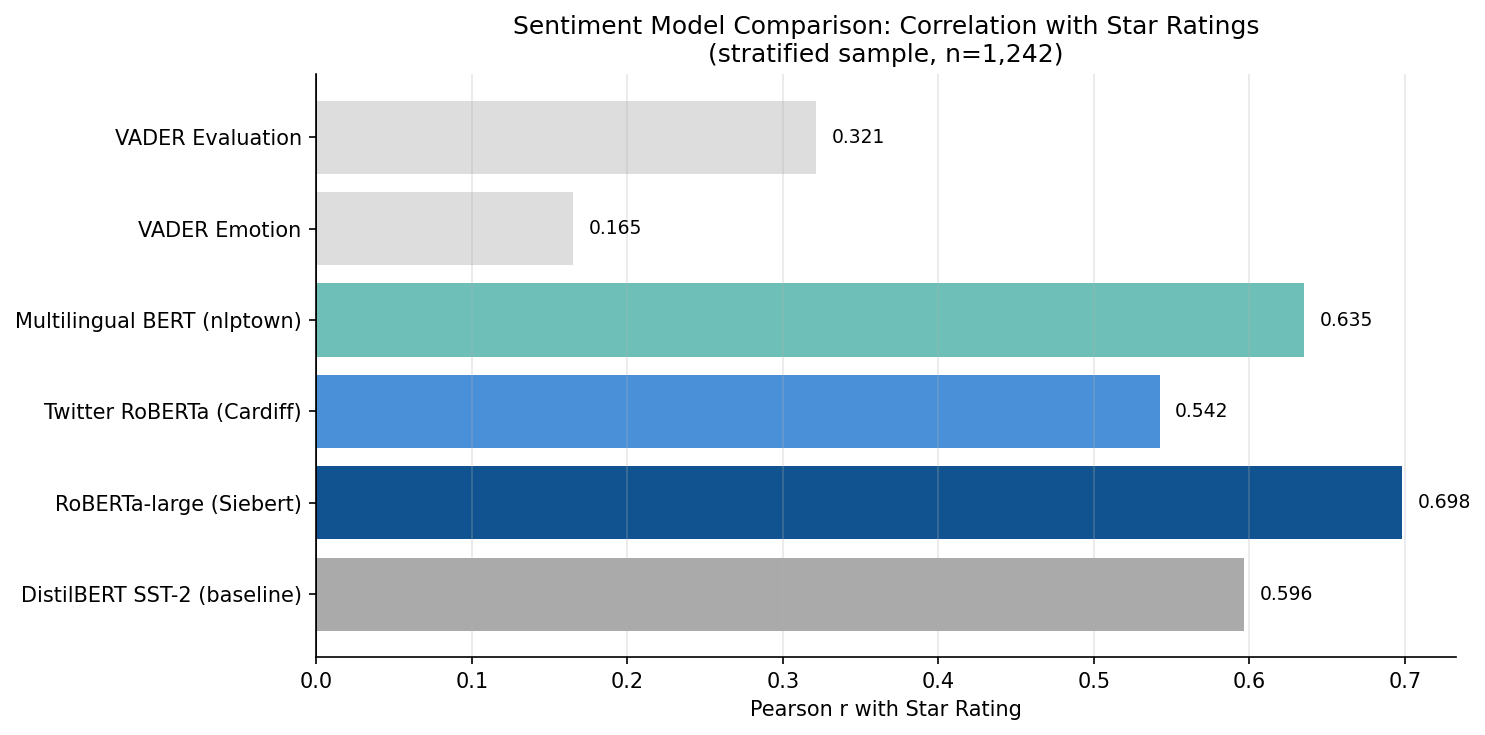

In [9]:
labels = list(model_cols.keys())
cols   = list(model_cols.values())
r_vals = [pearsonr(sample[c], sample['rating'])[0]
           for c in cols if c in sample.columns]
labels = [l for l, c in zip(labels, cols) if c in sample.columns]

colors = ['#aaaaaa' if 'baseline' in l else
          '#115391' if 'Siebert' in l else
          '#4a90d9' if 'Twitter' in l else
          '#6dbfb8' if 'nlptown' in l else
          '#dddddd' for l in labels]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, r_vals, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with Star Rating')
ax.set_title('Sentiment Model Comparison: Correlation with Star Ratings\n(stratified sample, n=1,242)')
for bar, val in zip(bars, r_vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../Outputs/Figures/model_comparison_correlation.png', dpi=300)
plt.show()


## 5. Inter-Model Agreement


In [10]:
transformer_cols = ['score_distilbert', 'score_roberta_siebert',
                    'score_twitter', 'score_multilingual']
transformer_cols = [c for c in transformer_cols if c in sample.columns]

print('Inter-model Pearson correlation matrix:')
corr_df = sample[transformer_cols].corr()
corr_df.columns = ['DistilBERT', 'RoBERTa-Siebert', 'Twitter', 'Multilingual']
corr_df.index   = corr_df.columns
print(corr_df.round(3).to_string())


Inter-model Pearson correlation matrix:
                 DistilBERT  RoBERTa-Siebert  Twitter  Multilingual
DistilBERT            1.000            0.678    0.596         0.640
RoBERTa-Siebert       0.678            1.000    0.611         0.678
Twitter               0.596            0.611    1.000         0.667
Multilingual          0.640            0.678    0.667         1.000


## 6. Memorial Paradox Rates Across Models


In [11]:
# High-star (4-5) but model scores negative
high_star = sample[sample['rating'] >= 4]
print(f'High-star reviews (4-5★): {len(high_star)}')
print()

model_labels = {
    'score_distilbert':      'DistilBERT SST-2 (baseline)',
    'score_roberta_siebert': 'RoBERTa-large (Siebert)',
    'score_twitter':         'Twitter RoBERTa (Cardiff)',
    'score_multilingual':    'Multilingual BERT (nlptown)',
}

print(f'{"Model":<35} {"Paradox n":>10} {"Paradox %":>10}')
print('-' * 58)
for col, label in model_labels.items():
    if col not in sample.columns:
        continue
    paradox_n   = (high_star[col] < 0).sum()
    paradox_pct = paradox_n / len(high_star) * 100
    marker = ' ◀ baseline' if 'baseline' in label else ''
    print(f'{label:<35} {paradox_n:>10} {paradox_pct:>9.1f}%{marker}')


High-star reviews (4-5★): 700

Model                                Paradox n  Paradox %
----------------------------------------------------------
DistilBERT SST-2 (baseline)                131      18.7% ◀ baseline
RoBERTa-large (Siebert)                     53       7.6%
Twitter RoBERTa (Cardiff)                  189      27.0%
Multilingual BERT (nlptown)                 74      10.6%


In [12]:
# Which reviews are flagged as paradox by ALL models?
available = [c for c in model_labels if c in sample.columns]
paradox_flags = high_star[[c for c in available]].apply(lambda x: x < 0)
all_agree = paradox_flags.all(axis=1)
any_agree = paradox_flags.any(axis=1)

print(f'Flagged paradox by ALL {len(available)} models:  {all_agree.sum()} reviews')
print(f'Flagged paradox by ANY model:     {any_agree.sum()} reviews')
print()
print('Reviews flagged by all models (Memorial Paradox consensus):')
consensus = high_star[all_agree][['rating', 'reviewer_location', 'review_text'] + available]
for _, row in consensus.head(5).iterrows():
    print(f'\n★{int(row["rating"])} | {row["reviewer_location"]}')
    scores = {col.replace("score_",""): f'{row[col]:.2f}' for col in available}
    print(f'  Scores: {scores}')
    print(f'  {str(row["review_text"])[:350]}...')


Flagged paradox by ALL 4 models:  21 reviews
Flagged paradox by ANY model:     262 reviews

Reviews flagged by all models (Memorial Paradox consensus):

★4 | nan
  Scores: {'distilbert': '-1.00', 'roberta_siebert': '-1.00', 'twitter': '-0.35', 'multilingual': '-0.50'}
  You know I am on the fence about this museum.  On one hand it was humbling, everyone needs to know about the history and the 1st hand accounts.  On the other hand, the issue to me was the execution.  There were just too many people to take in everything this museum had to offer.   There were areas in the museum where it bottle necked and you were 3...

★4 | Phoenix, Arizona
  Scores: {'distilbert': '-0.98', 'roberta_siebert': '-1.00', 'twitter': '-0.88', 'multilingual': '-0.50'}
  This is a necessary, but very emotional and difficult museum to view.  We need experience this, but you will leave feeling heavy-hearted.  I do not recommend this for small children....

★4 | Auburn, Massachusetts
  Scores: {'distilbert': '-0.

## 7. Multilingual Bonus: German-Language Reviews

The `nlptown` model supports German (and Hebrew to a lesser extent).
This cell scores the 22 German-language reviews — the only model in this
pipeline that can do so.


In [13]:
# Load the full Excel to get German-language reviews
import warnings
raw = pd.read_excel('../Data/Raw/ushmm_tripadvisor_full.xlsx')
german_de = raw[
    (raw['lang'] == 'de') &
    (raw['user/userLocation/name'].str.contains(r'Germany$|, Germany', case=False, na=False))
][['rating', 'user/userLocation/name', 'text']].copy()
german_de.columns = ['rating', 'reviewer_location', 'review_text']
print(f'German-language reviews from Germany: {len(german_de)}')
print(german_de['rating'].value_counts().sort_index())


German-language reviews from Germany: 22
rating
3     2
4     3
5    17
Name: count, dtype: int64


In [14]:
de_texts = german_de['review_text'].astype(str).tolist()
german_de['score_multilingual'] = score_multilingual(
    de_texts, 'nlptown/bert-base-multilingual-uncased-sentiment'
)

print('German-language review scores (nlptown):')
print(f'Mean score: {german_de["score_multilingual"].mean():.3f}')
print(f'Correlation with rating: {pearsonr(german_de["score_multilingual"], german_de["rating"])[0]:.3f} (n={len(german_de)}, interpret cautiously)')
print()
print('Score by rating:')
print(german_de.groupby('rating')['score_multilingual'].agg(['mean','count']).round(3))

# Paradox check
high_star_de = german_de[german_de['rating'] >= 4]
paradox_de = (high_star_de['score_multilingual'] < 0).sum()
print(f'\nGerman paradox reviews (4-5★, negative score): {paradox_de} / {len(high_star_de)}')
if paradox_de > 0:
    for _, row in high_star_de[high_star_de['score_multilingual'] < 0].iterrows():
        print(f'\n★{int(row["rating"])} | {row["reviewer_location"]} | score={row["score_multilingual"]:.2f}')
        print(str(row['review_text'])[:400])


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1688.30it/s]


German-language review scores (nlptown):
Mean score: 0.568
Correlation with rating: 0.376 (n=22, interpret cautiously)

Score by rating:
         mean  count
rating              
3      -0.250      2
4       0.667      3
5       0.647     17

German paradox reviews (4-5★, negative score): 1 / 20

★5 | Reutlingen, Germany | score=-1.00
Der Besuch des Museums macht einen betroffen und zeigt einem, dass so etwas nie wieder geschehen darf. Vor allem die gezeigten Originalfilme sowie die Zeichnungen der Kinder gehen einem total unter die Haut.
Einen absolutes "Muss" bei einem Besuch der US-Hauptstadt.


## 8. Summary


In [15]:
print('=' * 65)
print('MODEL COMPARISON SUMMARY')
print('=' * 65)
print(f'{"Model":<35} {"r":>6} {"Paradox %":>10} {"Notes"}')
print('-' * 65)

notes = {
    'score_distilbert':      'baseline, binary, SST-2',
    'score_roberta_siebert': 'binary, 15-dataset mix',
    'score_twitter':         '3-class, social media',
    'score_multilingual':    '5-star, multilingual',
}
for col, label in model_labels.items():
    if col not in sample.columns:
        continue
    r = pearsonr(sample[col], sample['rating'])[0]
    p = (high_star[col] < 0).mean() * 100
    print(f'{label:<35} {r:>6.3f} {p:>9.1f}%   {notes[col]}')
print()
print('VADER channels (for reference):')
for col, label in [('emo_vader', 'VADER Emotion'), ('eval_vader', 'VADER Evaluation')]:
    r = pearsonr(sample[col], sample['rating'])[0]
    print(f'{label:<35} {r:>6.3f}')


MODEL COMPARISON SUMMARY
Model                                    r  Paradox % Notes
-----------------------------------------------------------------
DistilBERT SST-2 (baseline)          0.596      18.7%   baseline, binary, SST-2
RoBERTa-large (Siebert)              0.698       7.6%   binary, 15-dataset mix
Twitter RoBERTa (Cardiff)            0.542      27.0%   3-class, social media
Multilingual BERT (nlptown)          0.635      10.6%   5-star, multilingual

VADER channels (for reference):
VADER Emotion                        0.165
VADER Evaluation                     0.321


## 9. Save


In [16]:
sample.to_csv('../Data/Processed/ushmm_model_comparison.csv', index=False)
print(f'Saved {len(sample)} rows with all model scores to ushmm_model_comparison.csv')
print(f'Columns: {[c for c in sample.columns if "score" in c]}')


Saved 1242 rows with all model scores to ushmm_model_comparison.csv
Columns: ['score_distilbert', 'score_roberta_siebert', 'score_twitter', 'score_multilingual']
